### Task 1: Problem Definition & Dataset Selection

# Hotel Booking Analytics: Booking Trends, Cancellation Patterns and Revenue Performance

## Data Analytics Final Project

### Project Domain
Hospitality Industry

### Project Objective
The objective of this project is to analyse hotel booking data to understand booking patterns, cancellation behaviour and revenue-related trends.

The analysis will examine booking seasonality, hotel type, customer segments, lead time, length of stay, average daily rate, cancellations and other booking characteristics.

Python will be used for data loading, data cleaning, exploratory data analysis, statistical summaries and data visualisation.

### Dataset Source
Hotel Booking Demand dataset obtained from Kaggle. Link:- https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

### Main Analysis Focus
Booking Trends, Cancellation Patterns and Revenue Performance


### Key Questions

1. What are the overall booking and cancellation patterns?
2. Which hotel type receives the highest number of bookings?
3. How do bookings change across different months and seasons?
4. What is the cancellation rate for each hotel type?
5. Which customer and market segments generate the most bookings?
6. How does lead time relate to booking cancellations?
7. How does Average Daily Rate (ADR) vary across hotel types and time periods?
8. What are the most common lengths of stay?
9. Which countries generate the highest number of bookings?
10. What factors appear to be associated with booking cancellations and revenue performance?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("../Dataset/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.shape

(119390, 32)

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 119390
Number of columns: 32


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### Dataset Structure

The dataset contains 119,390 hotel booking records and 32 columns.

It contains a mixture of:

- Numerical variables such as lead time, number of guests, booking changes and previous cancellations.
- Categorical variables such as hotel type, arrival month, meal type, country and market segment.
- Some columns contain missing values, including `children`, `country` and `agent`.



In [10]:
# Statistical summary of numerical columns
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


### Observations from Statistical Summary of Numeric Column

Key initial observations include:

- Approximately 37% of bookings are marked as cancelled.
- Lead time ranges from 0 to 737 days, with an average of approximately 104 days.
- The booking data covers arrival years from 2015 to 2017.
- Weekend stays range from 0 to 19 nights.
- Weeknight stays range from 0 to 50 nights.


At this stage, these are only initial observations and no conclusions are being made until further analysis is completed.

In [12]:
# Statistical summary of categorical columns
df.describe(include="object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


### Categorical Summary Observations

The dataset contains several categorical variables related to hotel type, booking period, customer characteristics and booking channels.

Key initial observations include:

- There are two hotel types, with City Hotel being the most common.
- August has the highest number of booking records.
- BB is the most common meal category.
- The dataset contains bookings from 177 different country categories.
- Online TA is the most common market segment.
- TA/TO is the most common distribution channel.
- Room type A is the most frequently reserved and assigned room type.
- Most bookings have no deposit.
- Transient is the most common customer type.
- The **country** column contains some missing values and will require further investigation during data preprocessing.

###  Task 2: Data Cleaning & Pre-processing

In [13]:

df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Missing Values

The dataset contains missing values in four columns:

- **children**: 4 missing values
- **country**: 488 missing values
- **agent**: 16,340 missing values
- **company**: 112,593 missing values



In [14]:

df["children"] = df["children"].fillna(0)

df["country"] = df["country"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [15]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

### Missing Value Treatment

Missing values were handled based on the meaning of each column:

- children was filled with 0 to represent no children recorded.
- country was filled with "Unknown" because it is a categorical field.
- agent and company were filled with 0 to represent no recorded agent or company.

After treatment, the dataset contains no missing values.

In [16]:

df.duplicated().sum()

np.int64(31994)

In [17]:
df = df.drop_duplicates()
df.shape

(87396, 32)

### Duplicate Records

The dataset contained 31,994 fully duplicated rows.

These exact duplicate records were removed using drop,After removing duplicates, 87,396 unique booking records remained.

In [19]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [21]:
# Converting data types

df["children"] = df["children"].astype(int)
df["agent"] = df["agent"].astype(int)
df["company"] = df["company"].astype(int)

df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

In [22]:
df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

### Data Type Correction

The data types were reviewed and corrected where necessary.

**children**, **agent**, and **company** were converted from float to integer, because they represent whole-number values or identifier codes
**reservation_status_date** was converted from object to datetime format.
The remaining columns were already stored in appropriate data types.





 

### Creating Derived Columns

In [23]:

df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str)
)

df[["arrival_date_year", "arrival_date_month", "arrival_date_day_of_month", "arrival_date"]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


The **arrival_date** column was created by combining the existing year, month, and day columns into a single datetime field.

This makes date-based analysis easier, including monthly booking trends, seasonality, and time-based comparisons.

In [39]:
# Total stay duration for nights
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df[["stays_in_weekend_nights", "stays_in_week_nights", "total_stay_nights"]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


The **total_stay_nights** column was created by adding weekend-night stays and weekday-night stays.

This provides the total duration of each hotel booking and will be useful for analysing stay patterns and revenue-related trends.

In [26]:
#total number of guests
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

df[["adults", "children", "babies", "total_guests"]].head()

,adults,children,babies,total_guests
0,2,0,0,2
1,2,0,0,2
2,1,0,0,1
3,1,0,0,1
4,2,0,0,2


The **total_guests** column was created by adding the number of adults, children, and babies in each booking.

This provides the total number of guests per booking and will help analyse booking size, customer patterns, and revenue-related trends.

In [32]:
df[df["total_guests"] == 0].shape

(166, 35)

### Checking Invalid or Unusual Bookings

A total of 166 records were found with zero guests.

Since a valid hotel booking would normally contain at least one guest, these records were cinsidered as wrong and removed

In [34]:

df[df["total_guests"] == 0][[
    "hotel",
    "is_canceled",
    "adults",
    "children",
    "babies",
    "total_stay_nights",
    "adr",
    "reservation_status"
]].head(10)

,hotel,is_canceled,adults,children,babies,total_stay_nights,adr,reservation_status
2224,Resort Hotel,0,0,0,0,3,0.0,Check-Out
2409,Resort Hotel,0,0,0,0,0,0.0,Check-Out
3181,Resort Hotel,0,0,0,0,3,0.0,Check-Out
3684,Resort Hotel,0,0,0,0,5,0.0,Check-Out
3708,Resort Hotel,0,0,0,0,6,0.0,Check-Out
4127,Resort Hotel,1,0,0,0,0,0.0,Canceled
9376,Resort Hotel,1,0,0,0,0,0.0,Canceled
31765,Resort Hotel,0,0,0,0,10,28.0,Check-Out
32029,Resort Hotel,0,0,0,0,1,0.0,Check-Out
32827,Resort Hotel,0,0,0,0,12,0.0,Check-Out


In [35]:
# Remove bookings with zero guests
df = df[df["total_guests"] > 0]


In [36]:
df.shape

(87230, 35)

### Removing Invalid Zero-Guest Bookings

A total of 166 records contained zero adults, zero children, and zero babies.

These records were considered invalid for the booking analysis because a valid hotel booking would normally include at least one guest.

Therefore, the zero-guest records were removed from the dataset.

In [39]:
# cross checking before moving to analysis
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (87230, 35)
Missing values: 0
Duplicate rows: 0


After preprocessing, the dataset contains 87,230 records and 35 columns.

- All missing values have been handled.
- Duplicate records have been removed for the current analysis.
- Invalid zero-guest bookings were removed.
- Required data types were corrected.
- New derived columns were created for analysis.

# Task 3: Exploratory Data Analysis & Visualizations

**Visual 1 :-Univariate analysis (hotel type)**

In [40]:

hotel_counts = df["hotel"].value_counts()
hotel_counts

hotel
City Hotel      53274
Resort Hotel    33956
Name: count, dtype: int64

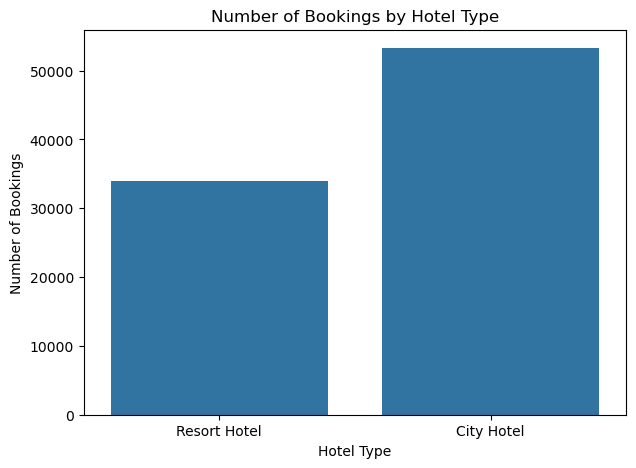

In [41]:
# Visual 1: Number of bookings by hotel type
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="hotel")
plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()

### Insight

City Hotel received a higher number of bookings compared with Resort Hotel.

This suggests that City Hotel has greater booking demand in the dataset.

**Visual 2 :- Univariate (arrival_date_month)**

In [42]:
monthly_bookings = df["arrival_date_month"].value_counts()
monthly_bookings

arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7489
October       6921
September     6682
February      6083
December      5112
November      4973
January       4685
Name: count, dtype: int64

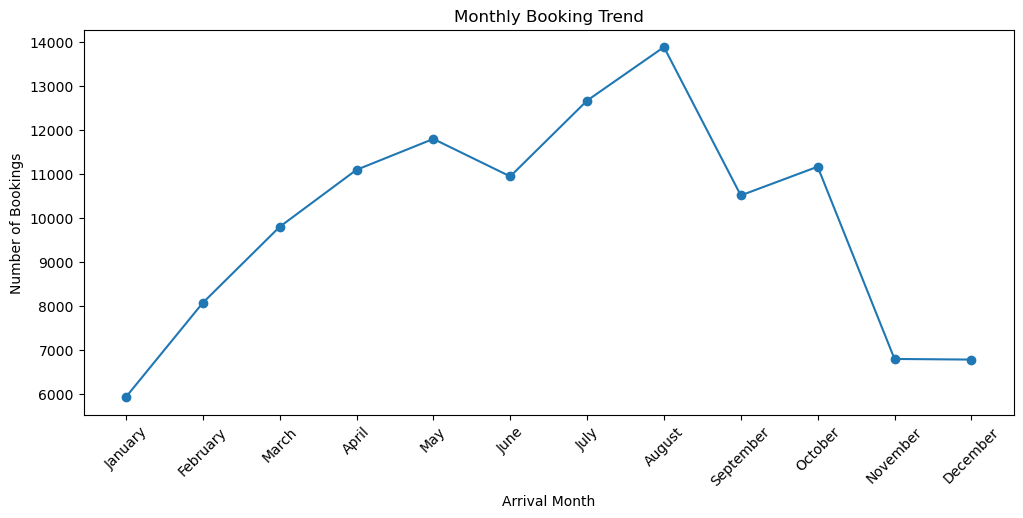

In [18]:
# Visual 2: Number of bookings by arrival month

monthly_bookings = (
    df.groupby("arrival_date_month")
    .size()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_bookings.index,
    monthly_bookings.values,
    marker="o"
)

plt.title("Monthly Booking Trend")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)

plt.show()

### Insight

Booking demand varies across the year, showing a clear seasonal pattern.

August has the highest number of bookings, followed by July, while January has the lowest number of bookings.

This suggests that hotel demand is strongest during the summer period and weaker at the beginning of the year.

**Visual 3: Univariate (Booking cancellation distribution)**

In [8]:
cancellation_counts = df["is_canceled"].value_counts()
cancellation_counts

is_canceled
0    75166
1    44224
Name: count, dtype: int64

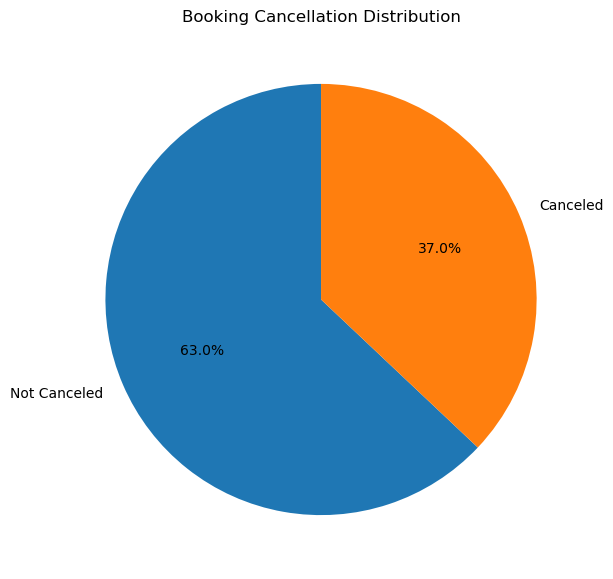

In [20]:
#Visual 3: Booking Cancellation Distribution

cancellation_counts = df["is_canceled"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    cancellation_counts,
    labels=["Not Canceled", "Canceled"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Booking Cancellation Distribution")
plt.show()


### Insight

Most hotel bookings were not cancelled. However, a significant number of bookings were cancelled, showing that cancellation behaviour is an important factor which will affect the total reve

**Visual 4:- Number of bookings by market segment**

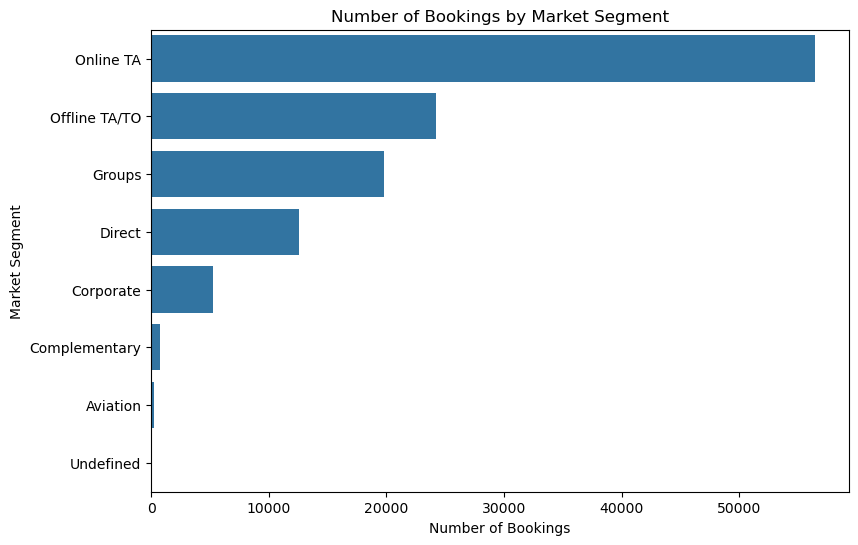

In [21]:
# Visual 4: Number of bookings by market segment

market_segment_counts = df["market_segment"].value_counts()

plt.figure(figsize=(9,6))

sns.barplot(
    x=market_segment_counts.values,
    y=market_segment_counts.index
)

plt.title("Number of Bookings by Market Segment")
plt.xlabel("Number of Bookings")
plt.ylabel("Market Segment")

plt.show()

### Insight

Online Travel Agents (Online TA) generate the highest number of bookings by a large margin.

Offline TA/TO and Group bookings are the next most common segments, while direct and corporate bookings contribute a smaller share.

This indicates that travel-agent channels are the main source of hotel bookings in the dataset.

**Visual 5 :- Bivariate (Cancellation by Hotel Type)**

In [12]:
# cancellation status by hotel type
pd.crosstab(df["hotel"], df["is_canceled"])

is_canceled,0,1
hotel,,
City Hotel,46228,33102
Resort Hotel,28938,11122


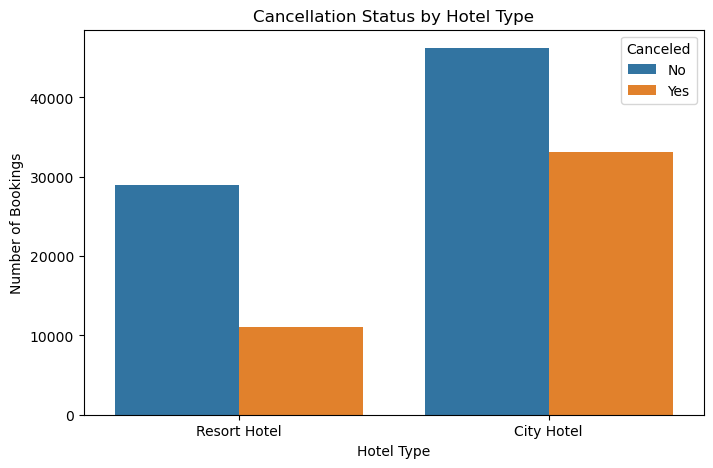

In [18]:
# Visual5 : (Cancellation by Hotel Type)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel",
    hue="is_canceled"
)

plt.title("Cancellation Status by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.legend(title="Canceled", labels=["No", "Yes"])

plt.show()

### Insight

City Hotel has a higher number of both cancelled and non-cancelled bookings compared with Resort Hotel.

However, since City Hotel also has more total bookings, cancellation counts alone are not enough to determine which hotel has the higher cancellation rate. Therefore, cancellation percentages should also be compared.

**Visual 6:- Bivariate (Cancellation Rate by Hotel Type)**

In [7]:
cancellation_rate = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index()
)

cancellation_rate

,hotel,is_canceled
0,City Hotel,41.726963
1,Resort Hotel,27.763355


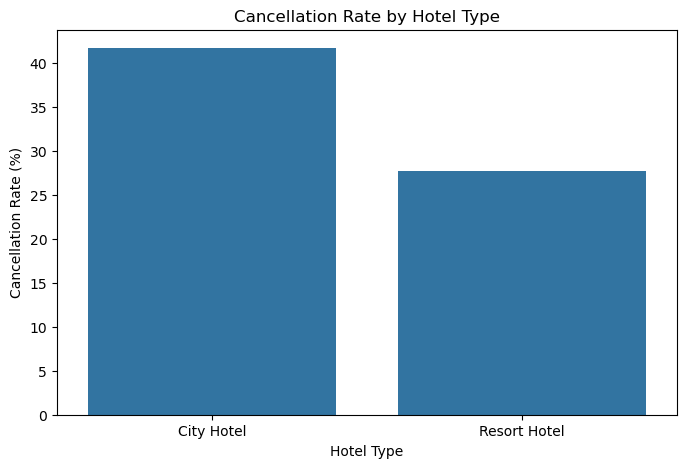

In [22]:
#Visual 6:- (Cancellation Rate by Hotel Type)

plt.figure(figsize=(8,5))

sns.barplot(
    data=cancellation_rate,
    x="hotel",
    y="is_canceled"
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

### Insight

City Hotel has a higher cancellation rate than Resort Hotel.

Approximately 41.7% of City Hotel bookings were cancelled, compared with about 27.8% for Resort Hotel.

This indicates that cancellation is a greater issue for City Hotel and may require further investigation into factors such as lead time, market segment, deposit type, and customer type.

**Visual 7:- Bivariate (Lead time by cancellation status)**

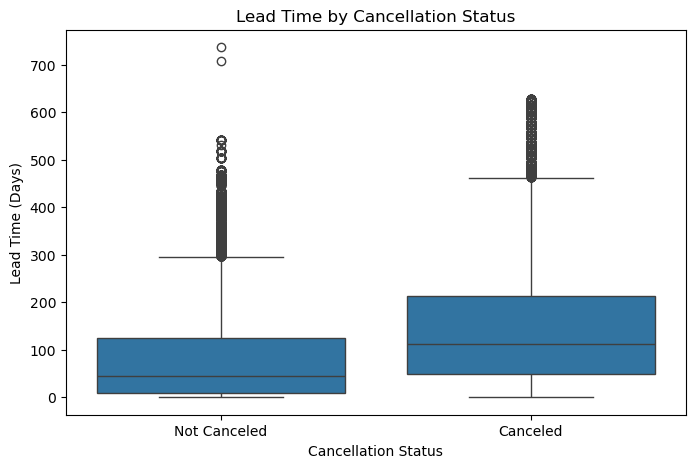

In [11]:
# Visual 7: Lead time by cancellation status

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="lead_time"
)

plt.title("Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")
plt.xticks([0, 1], ["Not Canceled", "Canceled"])

plt.show()


### Insight

Cancelled bookings generally have longer lead times than non-cancelled bookings.

This suggests that bookings made further in advance are more likely to be cancelled, while bookings made closer to the arrival date tend to have lower cancellation levels.

**Visual 8:- Bivariate (Average Daily Rate (ADR) by Hotel Type)**

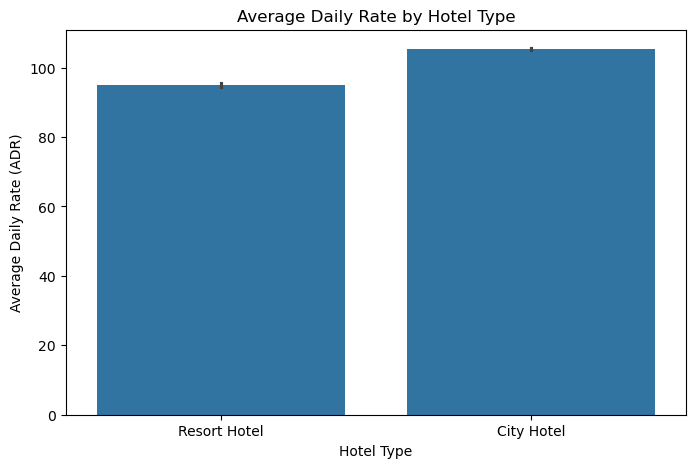

In [12]:
# Visual 8: Average Daily Rate by hotel type

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

### Insight

City Hotel has a higher average daily rate compared with Resort Hotel.

This indicates that, on average, guests pay a higher room rate at City Hotel than at Resort Hotel.

that tiny black mark is the confidence interva/uncertanity range bar that Seaborn adds

**Visual 9:- Bivariate (Average Daily Rate by arrival month)**

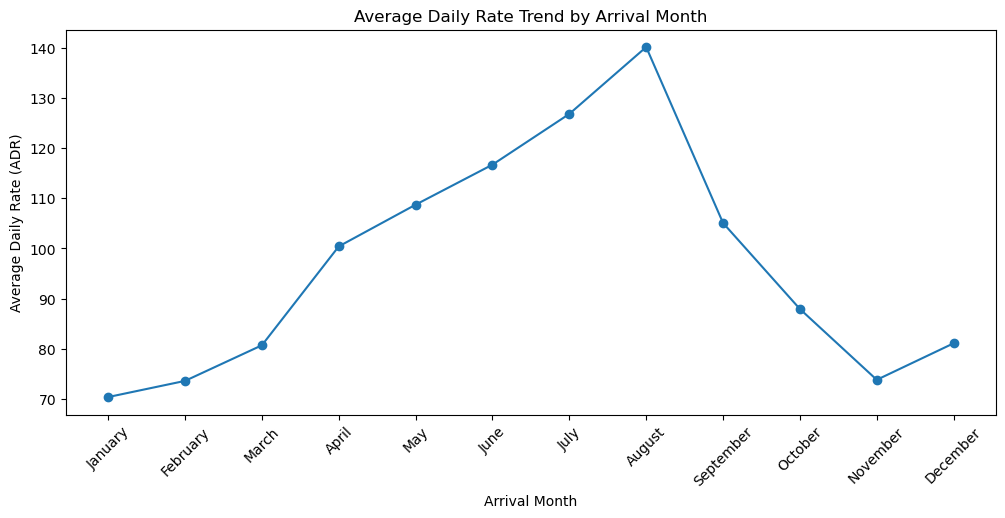

In [19]:
# Visual 9:- Average Daily Rate by arrival month

monthly_adr = (
    df.groupby("arrival_date_month")["adr"]
    .mean()
    .reindex(month_order)
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_adr.index,
    monthly_adr.values,
    marker="o"
)

plt.title("Average Daily Rate Trend by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Average Daily Rate (ADR)")
plt.xticks(rotation=45)

plt.show()

### Insight

Average Daily Rate (ADR) changes noticeably across the year.

ADR increases from the beginning of the year and reaches its highest level in August, before decreasing again in the later months.

This suggests that hotel room prices are highest during the peak summer season, when booking demand is also high.

**Visual 10:- Bivariate (Cancellation Rate by Market Segment)**

In [24]:
#  Calculating cancellation rate

market_cancel_rate = (
    df.groupby("market_segment")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

market_cancel_rate

,market_segment,is_canceled
0,Undefined,100.000000
1,Groups,61.062036
2,Online TA,36.721143
3,Offline TA/TO,34.316033
4,Aviation,21.940928
5,Corporate,18.734655
6,Direct,15.341901
7,Complementary,13.055182


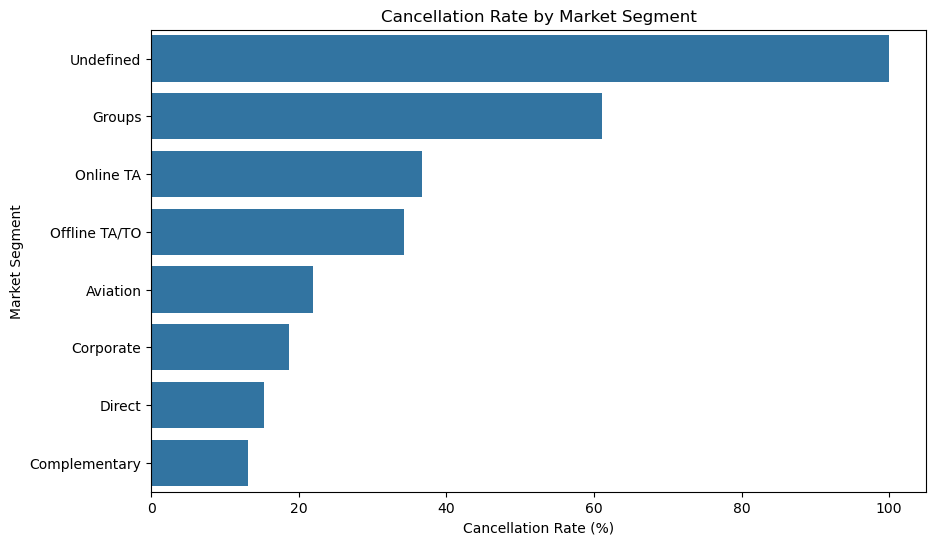

In [25]:
# Visual 10:- Cancellation rate by market segment

plt.figure(figsize=(10,6))

sns.barplot(
    data=market_cancel_rate,
    x="is_canceled",
    y="market_segment"
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")

plt.show()

### Insight

Cancellation rates vary considerably across market segments.

The Groups segment shows a relatively high cancellation rate among the major booking segments, followed by Online TA and Offline TA/TO.

The Undefined segment shows a 100% cancellation rate, but this category may contain very few bookings, so it should be interpreted with caution.

In [27]:
# Checking how many bookings are there in Undefined

df["market_segment"].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

### Insight

Cancellation rates vary across market segments.

Among the major booking segments, Groups has the highest cancellation rate, followed by Online TA and Offline TA/TO.

The  Undefined segment shows a 100% cancellation rate, but it contains only 2 bookings, so this result is not considered reliable for business interpretation.

**Visual 11: Multivariate (Monthly booking trend by hotel type)** 

In [30]:
# monthly booking counts by hotel type


monthly_hotel_bookings = (
    df.groupby(["arrival_date_month", "hotel"])
    .size()
    .reset_index(name="booking_count")
)

monthly_hotel_bookings["arrival_date_month"] = pd.Categorical(
    monthly_hotel_bookings["arrival_date_month"],
    categories=month_order,
    ordered=True
)

monthly_hotel_bookings = monthly_hotel_bookings.sort_values(
    "arrival_date_month"
)

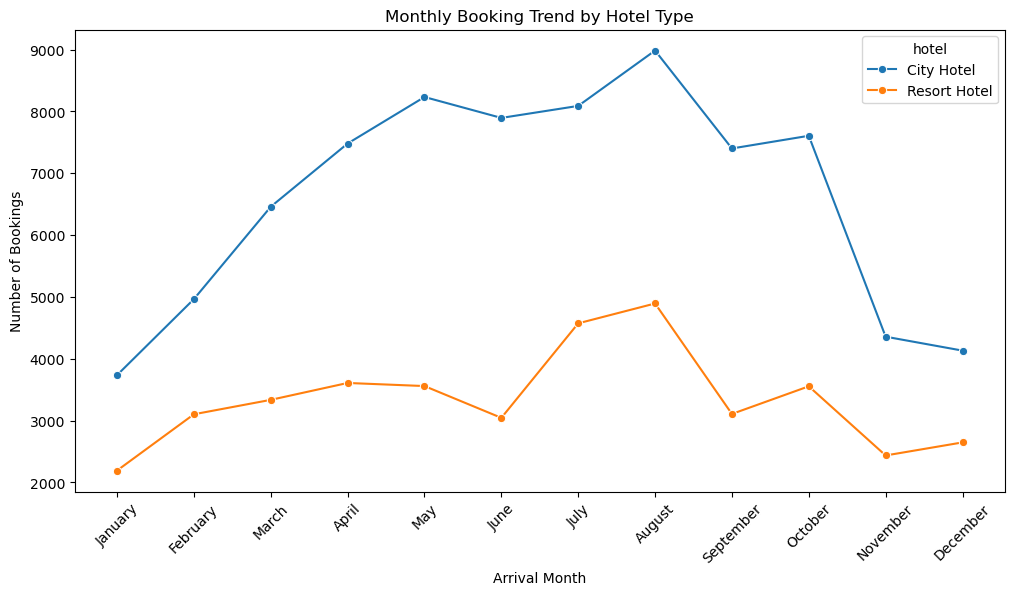

In [32]:
# Visual 11:- Monthly booking trend by hotel type

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_hotel_bookings,
    x="arrival_date_month",
    y="booking_count",
    hue="hotel",
    marker="o"
)

plt.title("Monthly Booking Trend by Hotel Type")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(
    ticks=range(len(month_order)),
    labels=month_order,
    rotation=45
)

plt.show()

### Insight

City Hotel records more bookings than Resort Hotel throughout the year.

Both hotel types show a seasonal pattern, with bookings increasing toward the summer months and reaching their highest levels in August.

Booking volumes decline noticeably toward the end of the year, particularly in November and December.

**Visual 12: Correlation heatmap**

In [35]:
# Selecting numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculating correlation matrix
correlation_matrix = numeric_df.corr()

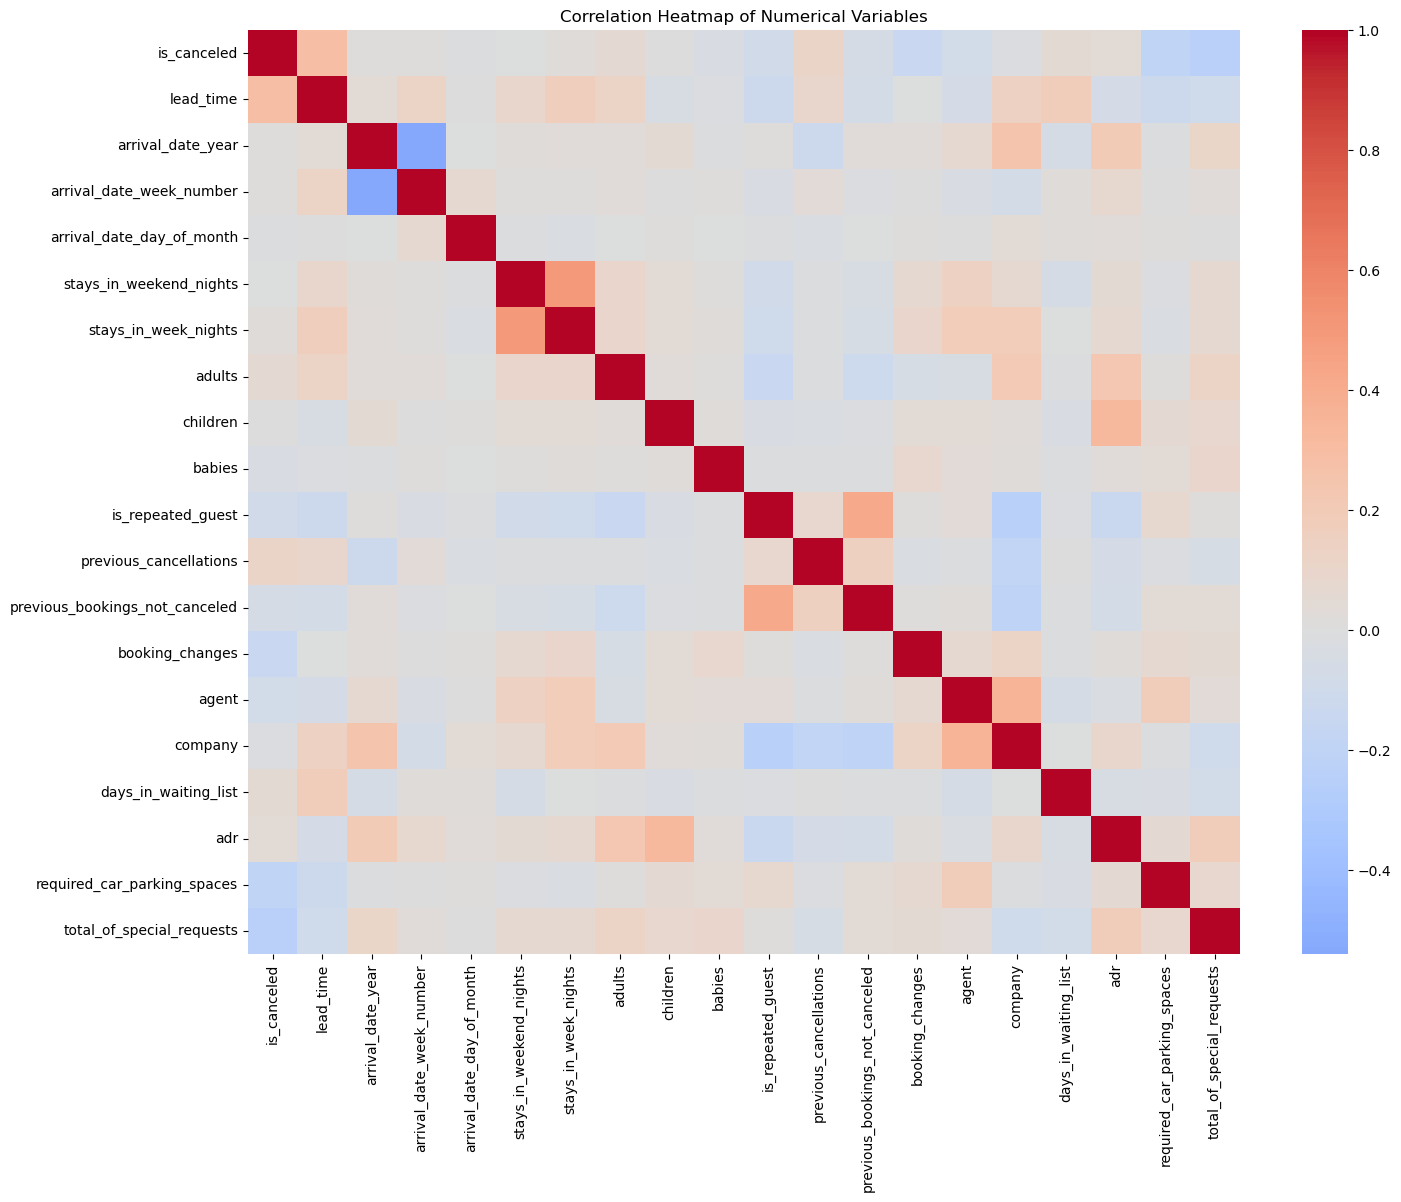

In [36]:
# Visual 12:- Correlation heatmap

plt.figure(figsize=(16,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### From the heatmap, some noticeable patterns are:

* stays_in_weekend_nights and stays_in_week_nights show a positive relationship, which makes sense because longer stays often include both weekday and weekend nights.
* is_repeated_guest and previous_bookings_not_canceled appear positively related.
* agent and company show some positive association.
* is_canceled appears to have only weak-to-moderate relationships with most numerical variables, which suggests cancellation is influenced by several  factors rather than one single numerical variable.
* lead_time shows some positive association with cancellation, which supports what we already saw in the box plot.

### Insight

The correlation heatmap shows that most numerical variables have weak to moderate relationships with each other.

Lead time shows a positive relationship with cancellation, supporting the earlier finding that bookings made further in advance are more likely to be cancelled.

Some other variables, such as previous booking history and stay duration measures, also show noticeable relationships. However, no single numerical variable appears to have a very strong relationship with cancellation.

### Pivot Table — Cancellation Rate by Hotel Type and Market Segment

In [37]:
cancellation_pivot = pd.pivot_table(
    df,
    values="is_canceled",
    index="hotel",
    columns="market_segment",
    aggfunc="mean"
) * 100

cancellation_pivot.round(2)

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
hotel,,,,,,,,
City Hotel,21.94,11.81,21.47,17.33,68.86,42.83,37.40,100.0
Resort Hotel,NaN,16.42,15.20,13.48,42.39,15.23,35.24,NaN


### Pivot Table Insight

The pivot table shows that cancellation rates vary by both hotel type and market segment.

The **Groups** segment has the highest cancellation rate for both hotel types, especially for City Hotel at approximately 68.9%.

City Hotel also shows higher cancellation rates than Resort Hotel across several major market segments, including Online TA and Offline TA/TO.

This suggests that both hotel type and booking channel are important factors when analysing cancellation behaviour.

### Overall Project KPIs


In [40]:
total_bookings = len(df)
cancellation_rate = df["is_canceled"].mean() * 100
average_adr = df["adr"].mean()
average_lead_time = df["lead_time"].mean()
average_stay = df["total_stay_nights"].mean()

print("Total Bookings:", total_bookings)
print("Overall Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Average ADR:", round(average_adr, 2))
print("Average Lead Time:", round(average_lead_time, 2), "days")
print("Average Stay Duration:", round(average_stay, 2), "nights")

Total Bookings: 119390
Overall Cancellation Rate: 37.04 %
Average ADR: 101.83
Average Lead Time: 104.01 days
Average Stay Duration: 3.43 nights


# Task 4: Documentation, Insights & Presentation

## Key Insights and Recommendations

### Key Insights

1. **City Hotel has higher booking demand but also a higher cancellation rate.**  
   City Hotel receives more bookings than Resort Hotel, but its cancellation rate is also significantly higher.

2. **Hotel demand is seasonal.**  
   Booking volumes rise toward the summer months and reach their highest level in August before declining later in the year.

3. **Average Daily Rate (ADR) follows the same seasonal pattern.**  
   ADR increases through the first half of the year, peaks in August, and then decreases afterward.

4. **Longer lead times are associated with higher cancellation levels.**  
   Cancelled bookings generally have longer lead times than non-cancelled bookings.

5. **Online Travel Agents generate the highest number of bookings.**  
   Online TA is the largest market segment, showing the importance of online booking channels.

6. **Group bookings have a relatively high cancellation rate.**  
   The Groups segment shows one of the highest cancellation rates among the major booking segments, especially for City Hotel.

7. **Cancellation behaviour is influenced by multiple factors.**  
   The correlation analysis shows that no single numerical variable has an extremely strong relationship with cancellation, indicating that several booking characteristics contribute to cancellation behaviour.

### Recommendations

- City Hotel should focus more on cancellation management because it has a higher cancellation rate than Resort Hotel.
- Bookings made far in advance could be supported with reminders, deposits, or suitable cancellation policies to reduce cancellation risk.
- Group bookings should be monitored more closely because they show relatively high cancellation rates.
- Hotels can use seasonal pricing strategies, especially during high-demand months such as July and August.
- Online Travel Agent channels should remain an important sales channel because they generate the highest booking volume.
- Promotions and targeted offers could be used during lower-demand months to improve occupancy.

## Conclusion


This project analysed hotel booking data to understand booking trends, cancellation patterns, market segments, and revenue-related behaviour.

The analysis identified clear seasonal patterns in both booking demand and Average Daily Rate, with the strongest activity occurring during the summer period.

**City Hotel** generated more bookings than Resort Hotel but also experienced a higher cancellation rate. Longer lead times and certain market segments, particularly group bookings, were associated with higher cancellation levels.

**Online Travel Agents** were the main source of bookings, highlighting the importance of digital booking channels.

Overall, the analysis shows how hotel booking data can support better pricing decisions, cancellation management, customer segmentation, and operational planning.

## Actions to Improve Hotel Sales



Based on the analysis, hotels can take the following actions to improve sales and revenue:

- Use seasonal pricing strategies to increase revenue during high-demand months.
- Offer promotions and special packages during low-demand periods to improve occupancy.
- Strengthen Online Travel Agent partnerships because they generate the highest booking volume.
- Introduce targeted offers for direct bookings to reduce dependency on third-party channels.
- Reduce cancellations through booking reminders, deposit policies, and flexible but controlled cancellation options.
- Develop special packages for groups while managing their higher cancellation risk.
- Use booking and customer data regularly to improve pricing, marketing, and occupancy planning.